<a href="https://colab.research.google.com/github/Aniruddha-png/ECSR/blob/main/KEY_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install xgboost imbalanced-learn graphviz


In [ ]:
# Cell 2
import os, random, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from graphviz import Digraph
import joblib

# reproducibility seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Libraries loaded.")


Libraries loaded.


In [ ]:
# Cell 3 - adjust paths if needed
FIXED_PATH = "/content/Fixed Text Typing Dataset.csv"
FREE_PATH  = "/content/Free Text Typing Dataset.csv"

fixed = pd.read_csv(FIXED_PATH, delimiter=';')
free  = pd.read_csv(FREE_PATH, delimiter=';')

print("Fixed shape:", fixed.shape)
print("Free shape: ", free.shape)

# combine both to increase training variety
df = pd.concat([fixed, free], axis=0, ignore_index=True)
print("Combined shape:", df.shape)
print(df.columns.tolist())


Fixed shape: (46871, 14)
Free shape:  (28412, 15)
Combined shape: (75283, 16)
['userId', 'emotionIndex', 'index', 'keyCode', 'keyDown', 'keyUp', 'D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'answer', '_id', 'userid']


In [ ]:
# Cell 4
candidate_feats = ['D1U1','D1U2','D1D2','U1D2','U1U2','D1U3','D1D3']
feat_cols = [c for c in candidate_feats if c in df.columns]
print("Using latency features:", feat_cols)
assert len(feat_cols) >= 3, "Need at least 3 timing features."

# keep needed columns
keep_cols = [c for c in ['userId','emotionIndex','index'] if c in df.columns] + feat_cols
df = df[keep_cols].copy()

# sort by session if index exists
if 'index' in df.columns:
    df = df.sort_values(['userId','emotionIndex','index']).reset_index(drop=True)

# numeric conversion & fillna
for c in feat_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

print(df.head())
print(df.shape)


Using latency features: ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3']
   userId emotionIndex  index   D1U1    D1U2    D1D2    U1D2    U1U2    D1U3  \
0    13.0            N  15303  128.0  1624.0  1485.0  1357.0  1496.0  2301.0   
1    13.0            N  15304  139.0   816.0   701.0   562.0   677.0  1035.0   
2    13.0            N  15305  115.0   334.0   247.0   132.0   219.0   718.0   
3    13.0            N  15306   87.0   471.0   380.0   293.0   384.0  1559.0   
4    13.0            N  15307   91.0  1179.0  1064.0   973.0  1088.0  1372.0   

     D1D3  
0  2186.0  
1   948.0  
2   627.0  
3  1444.0  
4  1249.0  
(75283, 10)


In [ ]:
# Cell 5 - windowing parameters
WIN = 128    # increase for more signal
STRIDE = 16  # overlap to produce more windows

X_windows = []
Y_labels = []

groups = df.groupby(['userId','emotionIndex'], sort=False)

for (uid, emo), g in groups:
    seq = g[feat_cols].values.astype(np.float32)
    T = seq.shape[0]
    if T < 8:
        continue
    start = 0
    while start + WIN <= T:
        X_windows.append(seq[start:start+WIN, :])
        Y_labels.append(emo)
        start += STRIDE
    # include tail if long enough and not included
    if T >= WIN and start < T:
        X_windows.append(seq[-WIN:, :])
        Y_labels.append(emo)

X_windows = np.array(X_windows)
Y_labels = np.array(Y_labels)
print("Windows shape:", X_windows.shape)
unique, counts = np.unique(Y_labels, return_counts=True)
print("Per-class counts:", dict(zip(unique, counts)))


Windows shape: (1654, 128, 7)
Per-class counts: {np.str_('A'): np.int64(118), np.str_('C'): np.int64(148), np.str_('H'): np.int64(66), np.str_('N'): np.int64(1205), np.str_('S'): np.int64(117)}


In [ ]:
# Cell 6 - stratified split by label to ensure classes appear in each split
X_temp, X_test, y_temp, y_test = train_test_split(X_windows, Y_labels, test_size=0.20, stratify=Y_labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=SEED)

print("Shapes -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

# label encode
le = LabelEncoder()
y_all = le.fit_transform(np.concatenate([y_train, y_val, y_test]))
# but we need per-split as ints:
y_train = le.transform(y_train)
y_val   = le.transform(y_val)
y_test  = le.transform(y_test)
n_classes = len(le.classes_)
print("Classes:", le.classes_, "n_classes:", n_classes)


Shapes -> train: (1058, 128, 7) val: (265, 128, 7) test: (331, 128, 7)
Classes: ['A' 'C' 'H' 'N' 'S'] n_classes: 5


In [ ]:
# Cell 7 - scaling per-channel using train stats
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_val_flat   = X_val.reshape(-1, X_val.shape[-1])
X_test_flat  = X_test.reshape(-1, X_test.shape[-1])

scaler.fit(X_train_flat)
X_train_scaled = scaler.transform(X_train_flat).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val_flat).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test_flat).reshape(X_test.shape)

print("Scaled shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)


Scaled shapes: (1058, 128, 7) (265, 128, 7) (331, 128, 7)


In [ ]:
# Cell 8 - augmentation utility (we'll use it to augment balanced SMOTE data)
def augment_jitter(X, noise_std=0.01, times=1):
    # X shape: (N, WIN, C)
    out = []
    for t in range(times):
        noise = np.random.normal(loc=0.0, scale=noise_std, size=X.shape).astype(np.float32)
        out.append(X + noise)
    return np.vstack(out)

print("Augmentation util ready.")


Augmentation util ready.


In [ ]:
# Cell 9 - SMOTE requires 2D -> flatten windows
X_train_flat2d = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
print("Before SMOTE class distribution:", np.bincount(y_train))

sm = SMOTE(random_state=SEED)
X_tr_sm, y_tr_sm = sm.fit_resample(X_train_flat2d, y_train)

# reshape back to (N_new, WIN, C)
Nnew = X_tr_sm.shape[0]
X_tr_sm = X_tr_sm.reshape(Nnew, X_train_scaled.shape[1], X_train_scaled.shape[2])
print("After SMOTE distribution:", np.bincount(y_tr_sm))


Before SMOTE class distribution: [ 75  94  43 771  75]
After SMOTE distribution: [771 771 771 771 771]


In [ ]:
# Cell 10 - augment the SMOTE-balanced set to increase variation
X_aug = augment_jitter(X_tr_sm, noise_std=0.01, times=1)   # double the data
y_aug = np.tile(y_tr_sm, 1)  # times=1 => no duplication of labels; if times>1 adjust accordingly

# If we used times>1, we should tile labels; here no change.
# Final training arrays:
X_train_final = X_aug
y_train_final = y_aug

print("Final training shape:", X_train_final.shape, np.bincount(y_train_final))


Final training shape: (3855, 128, 7) [771 771 771 771 771]


In [ ]:
# Cell 11
classes = np.unique(y_train_final)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_final)
class_weight = {int(k): float(v) for k, v in zip(classes, cw)}
print("Class weights for training:", class_weight)


Class weights for training: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


In [ ]:
# Cell 12
def build_resnet_cnn(win_len, n_feats, n_classes):
    inp = layers.Input(shape=(win_len, n_feats))

    def res_block(x, filters, k):
        shortcut = x
        x = layers.Conv1D(filters, k, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
        x = layers.Conv1D(filters, k, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.add([shortcut, x])
        x = layers.ReLU()(x)
        return x

    x = layers.Conv1D(128, 7, padding='same', kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)

    x = res_block(x, 128, 5)
    x = res_block(x, 128, 5)

    x = layers.Conv1D(256, 3, strides=2, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.ReLU()(x)
    x = res_block(x, 256, 3)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    embedding = layers.Dense(128, activation='relu', name="embedding")(x)
    out = layers.Dense(n_classes, activation='softmax')(embedding)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn = build_resnet_cnn(X_train_final.shape[1], X_train_final.shape[2], n_classes)
cnn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 7)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 128)  │      6,400 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     82,048 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 128)  │     82,048 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128)  │          0 │ re_lu[0][0],      │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 128)  │     82,048 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 128)  │     82,048 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128)  │          0 │ re_lu_2[0][0],    │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 128, 128)  │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 64, 256)   │     98,560 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 64, 256)   │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 64, 256)   │    196,864 │ re_lu_5[0][0]   

 Total params: 930,821 (3.55 MB)

 Trainable params: 928,517 (3.54 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
# Cell 13
early = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history = cnn.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early, reduce],
    verbose=1
)

# predictions & eval
cnn_val_probs = cnn.predict(X_val_scaled, verbose=0)
cnn_test_probs = cnn.predict(X_test_scaled, verbose=0)
print("CNN val accuracy:", accuracy_score(y_val, cnn_val_probs.argmax(axis=1)))
print("CNN test accuracy:", accuracy_score(y_test, cnn_test_probs.argmax(axis=1)))


Epoch 1/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 26s 157ms/step - accuracy: 0.3666 - loss: 1.5829 - val_accuracy: 0.0528 - val_loss: 2.0366 - learning_rate: 1.0000e-04
Epoch 2/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5676 - loss: 1.2470 - val_accuracy: 0.1019 - val_loss: 2.6551 - learning_rate: 1.0000e-04
Epoch 3/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7189 - loss: 0.9167 - val_accuracy: 0.1170 - val_loss: 3.4689 - learning_rate: 1.0000e-04
Epoch 4/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8464 - loss: 0.6006 - val_accuracy: 0.1472 - val_loss: 4.5119 - learning_rate: 1.0000e-04
Epoch 5/80
57/61 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9231 - loss: 0.3747
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9243 - loss: 0.3713 - val_accuracy: 0.1887 - val_loss: 4.7179 - learning_rate: 1.0000e-04
Epoch 6/80
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9610 - l

In [ ]:
# Cell 14
emb_model = models.Model(inputs=cnn.input, outputs=cnn.get_layer("embedding").output)
X_train_embed = emb_model.predict(X_train_final, verbose=0)
X_val_embed   = emb_model.predict(X_val_scaled, verbose=0)
X_test_embed  = emb_model.predict(X_test_scaled, verbose=0)

print("Embeddings shapes:", X_train_embed.shape, X_val_embed.shape, X_test_embed.shape)


Embeddings shapes: (3855, 128) (265, 128) (331, 128)


In [ ]:
# Cell 15
# Optionally apply SMOTE on embeddings
sm_e = SMOTE(random_state=SEED)
X_tr_emb_sm, y_tr_emb_sm = sm_e.fit_resample(X_train_embed, y_train_final)

xgb_emb = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
xgb_emb.fit(X_tr_emb_sm, y_tr_emb_sm)

xgb_val_probs = xgb_emb.predict_proba(X_val_embed)
xgb_test_probs = xgb_emb.predict_proba(X_test_embed)

print("XGB on embeddings val acc:", accuracy_score(y_val, xgb_val_probs.argmax(1)))
print("XGB on embeddings test acc:", accuracy_score(y_test, xgb_test_probs.argmax(1)))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:03:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB on embeddings val acc: 0.8264150943396227
XGB on embeddings test acc: 0.8217522658610272


In [ ]:
# Cell 16 - build summary features per window
def summarize_batch(batch):
    feats = []
    for seq in batch:
        f = []
        for c in range(seq.shape[1]):
            v = seq[:, c]
            f += [
                v.mean(), v.std(ddof=1) if len(v)>1 else 0.0,
                v.min(), v.max(), np.median(v),
                np.percentile(v,25), np.percentile(v,75)
            ]
        feats.append(f)
    return np.array(feats, dtype=np.float32)

X_train_sum = summarize_batch(X_train_final)  # careful: X_train_final aligned with y_train_final
X_val_sum   = summarize_batch(X_val_scaled)
X_test_sum  = summarize_batch(X_test_scaled)

# SMOTE on summary
sm_s = SMOTE(random_state=SEED)
X_tr_sum_sm, y_tr_sum_sm = sm_s.fit_resample(X_train_sum, y_train_final)

xgb_sum = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
xgb_sum.fit(X_tr_sum_sm, y_tr_sum_sm)

xgb_sum_val_probs = xgb_sum.predict_proba(X_val_sum)
xgb_sum_test_probs = xgb_sum.predict_proba(X_test_sum)

print("XGB on summary val acc:", accuracy_score(y_val, xgb_sum_val_probs.argmax(1)))
print("XGB on summary test acc:", accuracy_score(y_test, xgb_sum_test_probs.argmax(1)))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:04:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB on summary val acc: 0.8943396226415095
XGB on summary test acc: 0.8610271903323263


In [ ]:
# Cell 17 - soft voting (weighted average of probabilities)
# average probs from cnn, xgb_emb, xgb_sum - first get val probs for stacking
cnn_val_probs = cnn.predict(X_val_scaled, verbose=0)
cnn_test_probs = cnn.predict(X_test_scaled, verbose=0)

# combine xgb probs: we have xgb_emb and xgb_sum
xgb_val_probs = xgb_emb.predict_proba(X_val_embed)
xgb_test_probs = xgb_emb.predict_proba(X_test_embed)

xgbs_val_probs = xgb_sum_val_probs
xgbs_test_probs = xgb_sum_test_probs

# Weighted average (tune weights)
w_cnn, w_xgb_emb, w_xgb_sum = 0.5, 0.3, 0.2
meta_val_probs = w_cnn*cnn_val_probs + w_xgb_emb*xgb_val_probs + w_xgb_sum*xgbs_val_probs
meta_test_probs = w_cnn*cnn_test_probs + w_xgb_emb*xgb_test_probs + w_xgb_sum*xgbs_test_probs

# Soft-vote performance
y_pred_soft = meta_test_probs.argmax(axis=1)
print("Soft-vote accuracy:", accuracy_score(y_test, y_pred_soft))
print(classification_report(y_test, y_pred_soft, target_names=le.classes_))

# Stacking: train meta-learner on meta_val_probs -> predict on meta_test_probs
meta_clf = XGBClassifier(
    objective="multi:softmax",
    num_class=n_classes,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)
meta_clf.fit(meta_val_probs, y_val)
y_pred_stack = meta_clf.predict(meta_test_probs)
print("Stacked meta accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))


Soft-vote accuracy: 0.8610271903323263
              precision    recall  f1-score   support

           A       0.76      0.79      0.78        24
           C       0.75      0.70      0.72        30
           H       0.50      0.69      0.58        13
           N       0.92      0.91      0.92       241
           S       0.76      0.70      0.73        23

    accuracy                           0.86       331
   macro avg       0.74      0.76      0.74       331
weighted avg       0.87      0.86      0.86       331



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:06:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Stacked meta accuracy: 0.8882175226586103
              precision    recall  f1-score   support

           A       0.79      0.96      0.87        24
           C       0.86      0.80      0.83        30
           H       0.64      0.54      0.58        13
           N       0.93      0.94      0.93       241
           S       0.70      0.61      0.65        23

    accuracy                           0.89       331
   macro avg       0.78      0.77      0.77       331
weighted avg       0.89      0.89      0.89       331



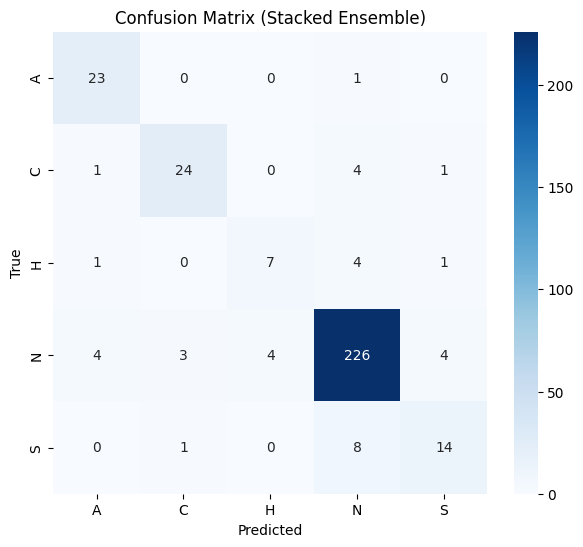

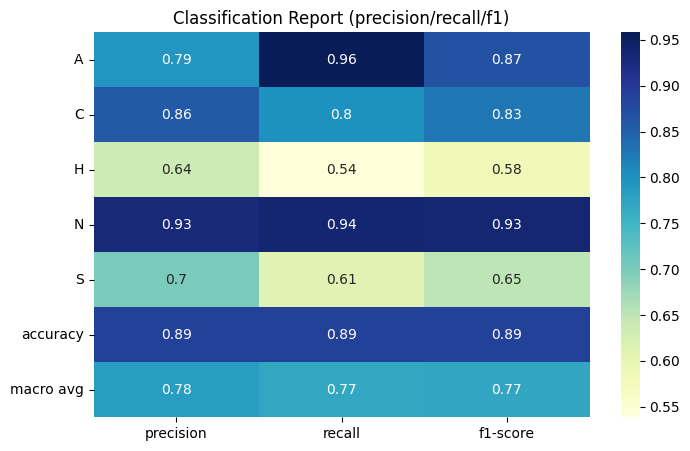

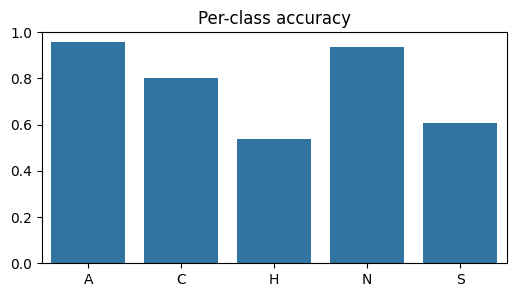

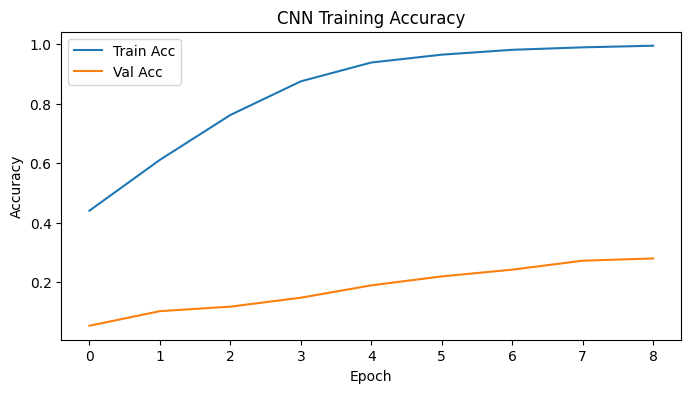

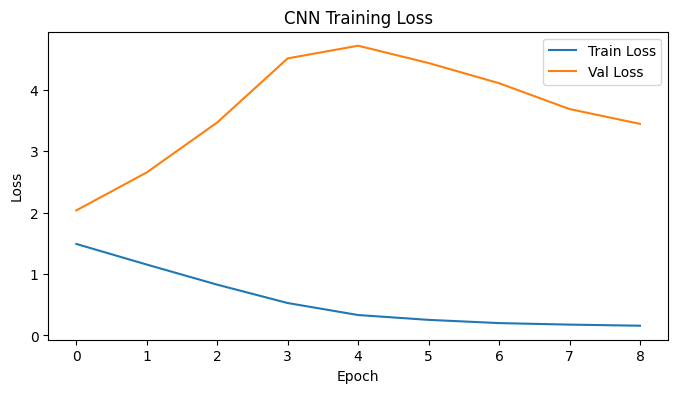

In [ ]:
# Cell 18 - plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# choose final predictions (stacked)
y_pred_final = y_pred_stack

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Confusion Matrix (Stacked Ensemble)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# classification report heatmap
report = classification_report(y_test, y_pred_final, target_names=le.classes_, output_dict=True)
df_report = pd.DataFrame(report).transpose()
plt.figure(figsize=(8,5))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu")
plt.title("Classification Report (precision/recall/f1)")
plt.show()

# per-class accuracy
class_acc = cm.diagonal()/cm.sum(axis=1)
plt.figure(figsize=(6,3))
sns.barplot(x=le.classes_, y=class_acc)
plt.ylim(0,1)
plt.title("Per-class accuracy")
plt.show()

# CNN training curves
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("CNN Training Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("CNN Training Loss")
plt.show()


In [ ]:
# Cell 19 - architecture diagram
dot = Digraph(comment="Ensemble Architecture", format="png")
dot.node("CNN", "CNN (ResNet-1D)\nExtracts temporal embedding\nOutputs: probabilities + embedding")
dot.node("XGB1", "XGB on Embeddings\n(probs)")
dot.node("XGB2", "XGB on Summary Stats\n(probs)")
dot.node("META", "Meta-learner (XGB)\nTrained on val-probs")
dot.node("OUT", "Final emotion label")

dot.edges([("CNN","XGB1"), ("CNN","META"), ("XGB1","META"), ("XGB2","META")])
dot.edge("META", "OUT")
dot.render("/content/ensemble_architecture", view=False)
print("Saved architecture to /content/ensemble_architecture.png")

# Cell 19 - save trained models & objects
cnn.save("/content/cnn_model.h5")
joblib.dump(xgb_emb, "/content/xgb_emb_model.pkl")
joblib.dump(xgb_sum, "/content/xgb_sum_model.pkl")
joblib.dump(meta_clf, "/content/meta_model.pkl")
joblib.dump(le, "/content/label_encoder.pkl")
joblib.dump(scaler, "/content/scaler.pkl")
print("Saved models and preprocessors to /content")


Saved architecture to /content/ensemble_architecture.png
Saved models and preprocessors to /content


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


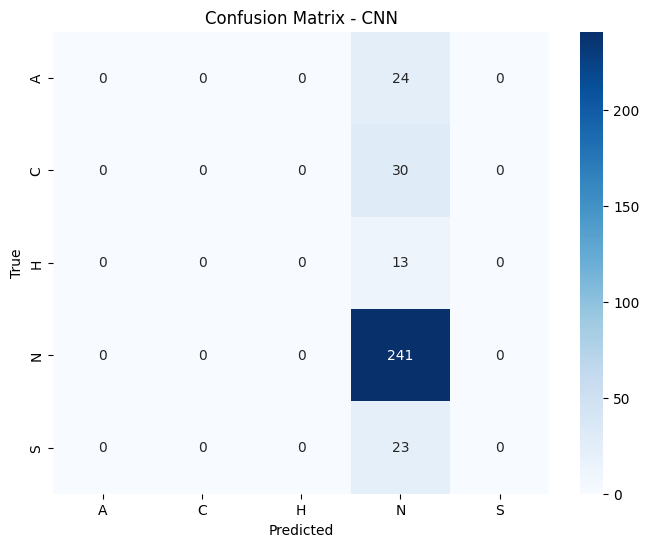

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predict on test set
y_pred_cnn = cnn.predict(X_test)
y_pred_cnn = y_pred_cnn.argmax(axis=1)

# Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CNN")
plt.show()


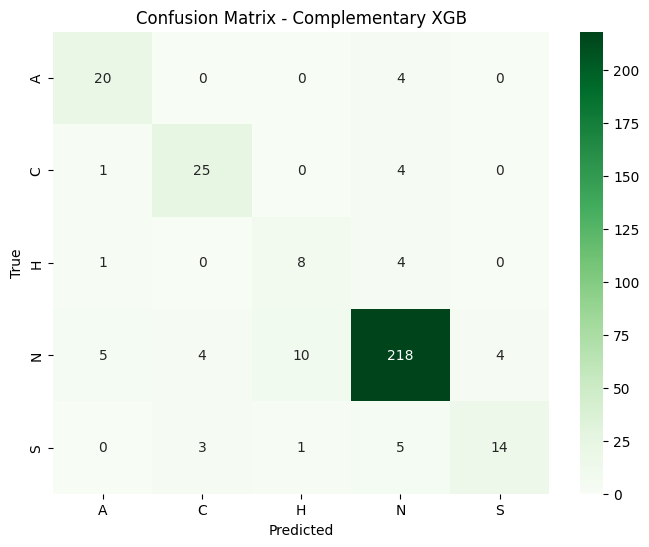

In [ ]:
# Predict on test set
y_pred_xgb = xgb_sum.predict(X_test_sum)   # X_test_summary = summary features for test
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Complementary XGB")
plt.show()


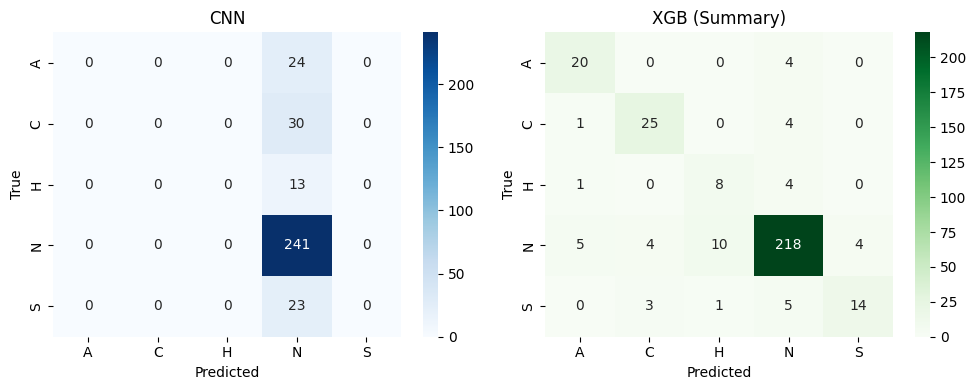

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("CNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("XGB (Summary)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


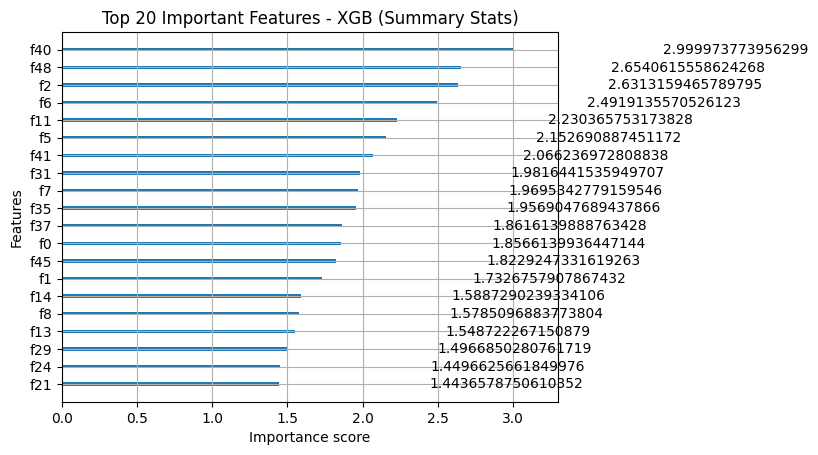

In [ ]:
import xgboost as xgb

xgb.plot_importance(xgb_sum, max_num_features=20, importance_type="gain")
plt.title("Top 20 Important Features - XGB (Summary Stats)")
plt.show()


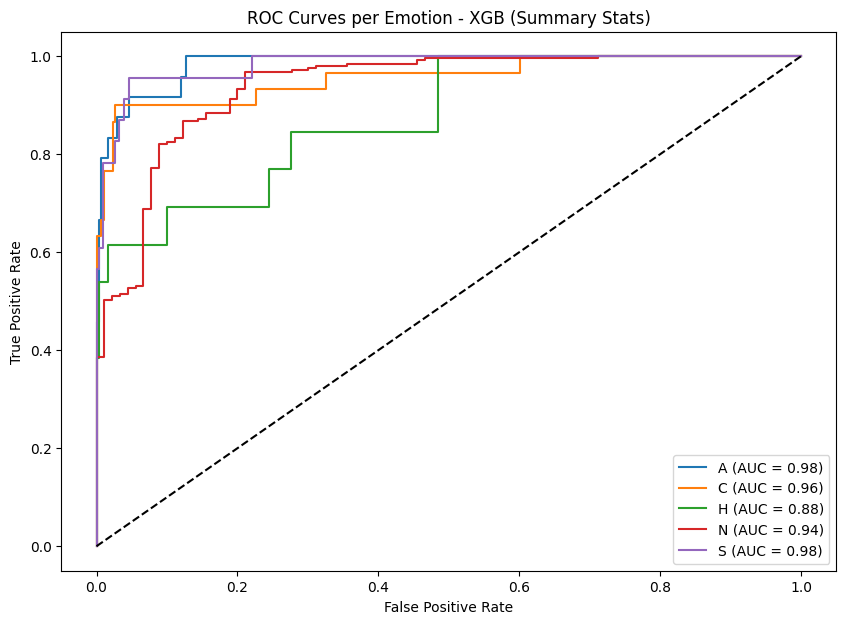

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
y_prob = xgb_sum.predict_proba(X_test_sum)

plt.figure(figsize=(10,7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {auc(fpr,tpr):.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Emotion - XGB (Summary Stats)")
plt.legend()
plt.show()


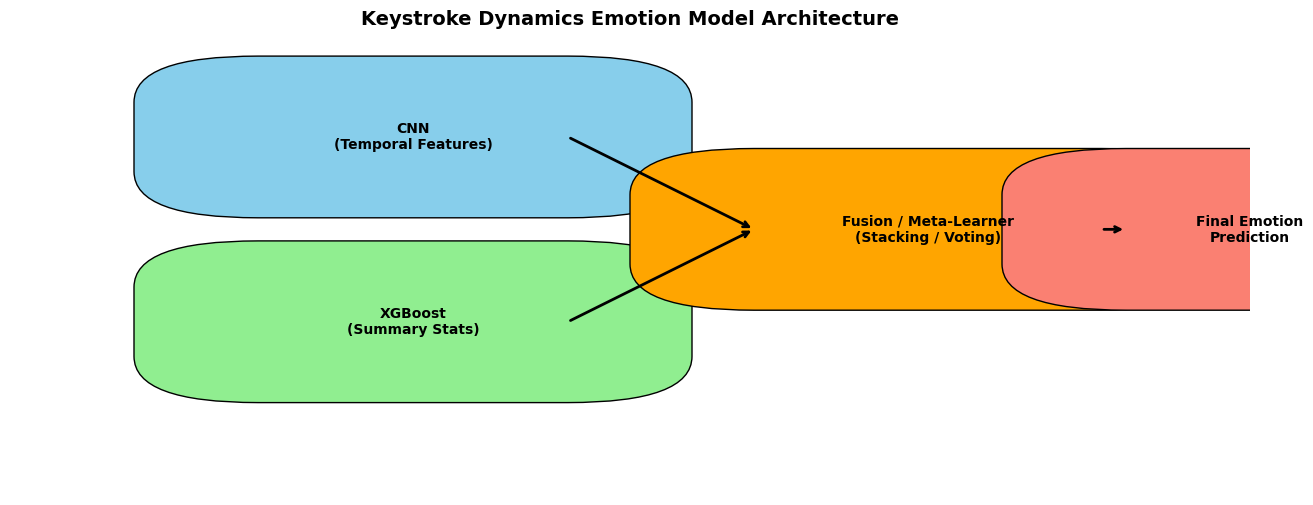

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_keystroke_architecture():
    fig, ax = plt.subplots(figsize=(16,6))

    # Remove axes
    ax.axis("off")

    # Define positions
    cnn_pos = (0.2, 0.7)
    xgb_pos = (0.2, 0.3)
    stack_pos = (0.6, 0.5)
    out_pos = (0.9, 0.5)

    # Draw boxes
    cnn_box = mpatches.FancyBboxPatch((cnn_pos[0], cnn_pos[1]), 0.25, 0.15,
                                      boxstyle="round,pad=0.1", fc="skyblue")
    xgb_box = mpatches.FancyBboxPatch((xgb_pos[0], xgb_pos[1]), 0.25, 0.15,
                                      boxstyle="round,pad=0.1", fc="lightgreen")
    stack_box = mpatches.FancyBboxPatch((stack_pos[0], stack_pos[1]), 0.28, 0.15,
                                        boxstyle="round,pad=0.1", fc="orange")
    out_box = mpatches.FancyBboxPatch((out_pos[0], out_pos[1]), 0.2, 0.15,
                                      boxstyle="round,pad=0.1", fc="salmon")

    ax.add_patch(cnn_box)
    ax.add_patch(xgb_box)
    ax.add_patch(stack_box)
    ax.add_patch(out_box)

    # Add text
    ax.text(cnn_pos[0]+0.125, cnn_pos[1]+0.075, "CNN\n(Temporal Features)",
            ha="center", va="center", fontsize=10, weight="bold")
    ax.text(xgb_pos[0]+0.125, xgb_pos[1]+0.075, "XGBoost\n(Summary Stats)",
            ha="center", va="center", fontsize=10, weight="bold")
    ax.text(stack_pos[0]+0.14, stack_pos[1]+0.075, "Fusion / Meta-Learner\n(Stacking / Voting)",
            ha="center", va="center", fontsize=10, weight="bold")
    ax.text(out_pos[0]+0.1, out_pos[1]+0.075, "Final Emotion\nPrediction",
            ha="center", va="center", fontsize=10, weight="bold")

    # Draw arrows
    ax.annotate("", xy=(stack_pos[0], stack_pos[1]+0.075),
                xytext=(cnn_pos[0]+0.25, cnn_pos[1]+0.075),
                arrowprops=dict(arrowstyle="->", lw=2))
    ax.annotate("", xy=(stack_pos[0], stack_pos[1]+0.075),
                xytext=(xgb_pos[0]+0.25, xgb_pos[1]+0.075),
                arrowprops=dict(arrowstyle="->", lw=2))
    ax.annotate("", xy=(out_pos[0], out_pos[1]+0.075),
                xytext=(stack_pos[0]+0.28, stack_pos[1]+0.075),
                arrowprops=dict(arrowstyle="->", lw=2))

    plt.title("Keystroke Dynamics Emotion Model Architecture", fontsize=14, weight="bold")
    plt.show()

# Call function
draw_keystroke_architecture()
